In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

Read the csv file and checking info

In [3]:
df = pd.read_csv('911.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   lat        99492 non-null  float64
 1   lng        99492 non-null  float64
 2   desc       99492 non-null  object 
 3   zip        86637 non-null  float64
 4   title      99492 non-null  object 
 5   timeStamp  99492 non-null  object 
 6   twp        99449 non-null  object 
 7   addr       98973 non-null  object 
 8   e          99492 non-null  int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 6.8+ MB


get top 5 rows 

In [4]:
df.head(5)

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1


In title i can add colmun named emergency to store the reason of calling (EMS , Fire , Traffic .. etc )
notice how string looks "EMS: BACK PAINS/INJURY". So i can split it on ":" 

In [5]:
df['emergency'] = df['title'].apply(lambda x : x.split(':')[0])


check the result of the new column

In [9]:
df['emergency']

0            EMS
1            EMS
2           Fire
3            EMS
4            EMS
          ...   
99487    Traffic
99488    Traffic
99489        EMS
99490        EMS
99491    Traffic
Name: emergency, Length: 99492, dtype: object

Get the most common reasons

In [10]:
df['emergency'].value_counts()

emergency
EMS        48877
Traffic    35695
Fire       14920
Name: count, dtype: int64

countplot:

<Axes: xlabel='emergency', ylabel='count'>

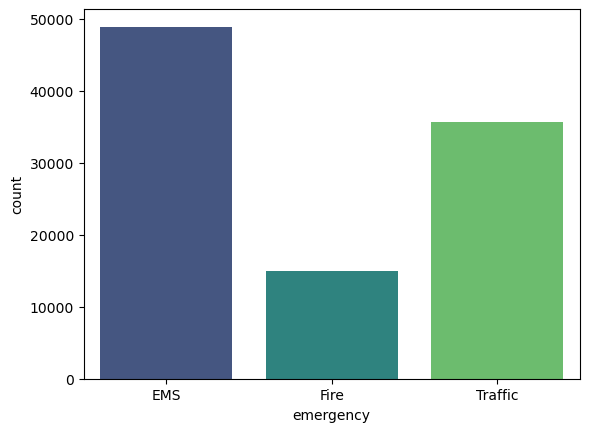

In [15]:
sns.countplot(x = 'emergency' , data = df , hue='emergency', palette = 'viridis') 

Based on info of the dataframe notice that  (timeStamp object) 
checking the type of this column to avoid being a string type

In [16]:
type(df['timeStamp'][0])

str

Turning it to dateTime type

In [22]:
df['timeStamp'] = pd.to_datetime(df['timeStamp'])


In [23]:
type(df['timeStamp'][0])

pandas._libs.tslibs.timestamps.Timestamp

checking the datatype also in info 

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   lat        99492 non-null  float64       
 1   lng        99492 non-null  float64       
 2   desc       99492 non-null  object        
 3   zip        86637 non-null  float64       
 4   title      99492 non-null  object        
 5   timeStamp  99492 non-null  datetime64[ns]
 6   twp        99449 non-null  object        
 7   addr       98973 non-null  object        
 8   e          99492 non-null  int64         
 9   emergency  99492 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(5)
memory usage: 7.6+ MB


Getting most common year for 911 calls

In [30]:
df['Year'] = df['timeStamp'].apply(lambda x : x.year)
df['Month'] = df['timeStamp'].apply(lambda x : x.month)
df['Day of Week'] = df['timeStamp'].apply(lambda x : x.dayofweek)


df['Year'].value_counts()

Year
2016    91523
2015     7969
Name: count, dtype: int64

In [26]:
df['Month'].value_counts()

Month
1     13205
7     12137
6     11786
2     11467
5     11423
4     11326
3     11101
8      9078
12     7969
Name: count, dtype: int64

<Axes: xlabel='Year', ylabel='count'>

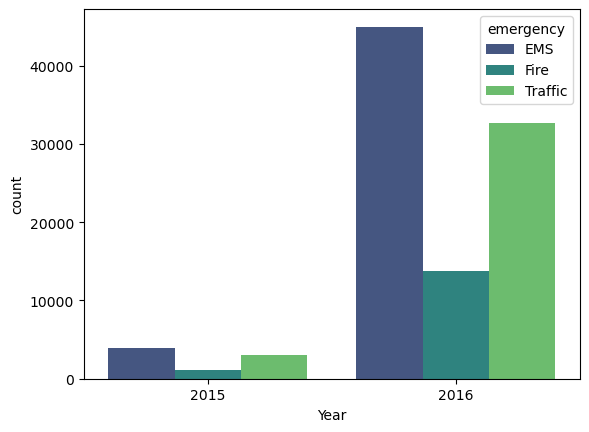

In [27]:
sns.countplot(x = 'Year' , data = df , hue='emergency', palette = 'viridis')

<Axes: xlabel='Year', ylabel='count'>

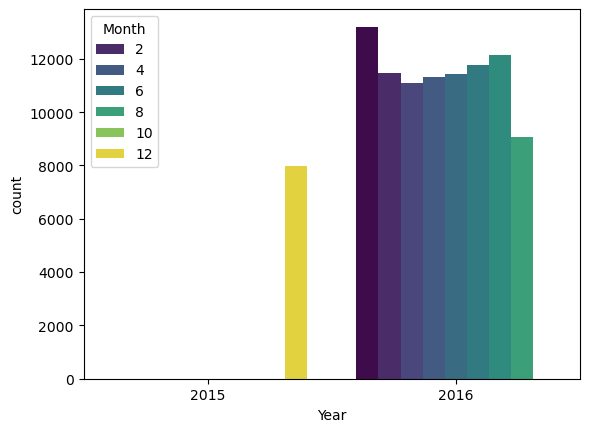

In [28]:
sns.countplot(x = 'Year' , data = df , hue='Month', palette = 'viridis')

Notice how the number of calls increases in the month of 1 and 2. This is because of the cold weather or snow. 
We can also see that the number of calls increases in the month of 7 and 8. This is because of the hot weather or heat.

selecting days :


In [48]:
df['Day of Week'] = df['timeStamp'].apply(lambda x : x.dayofweek)
df['Day of Week'].head()

0    3
1    3
2    3
3    3
4    3
Name: Day of Week, dtype: int64

Notice that day of week value uses indexs start from 0 (Mon) to 6 (Sun).Fixing it: 

In [49]:
dmap = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
df['Day of Week'] = df['Day of Week'].map(dmap)
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,emergency,Year,Month,hour,Day of Week
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1,EMS,2015,12,17,Thu
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1,EMS,2015,12,17,Thu
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1,Fire,2015,12,17,Thu
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1,EMS,2015,12,17,Thu
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1,EMS,2015,12,17,Thu


Notice how traffic emergencies reduce on weekends, which indicates that many people
prefer to stay home

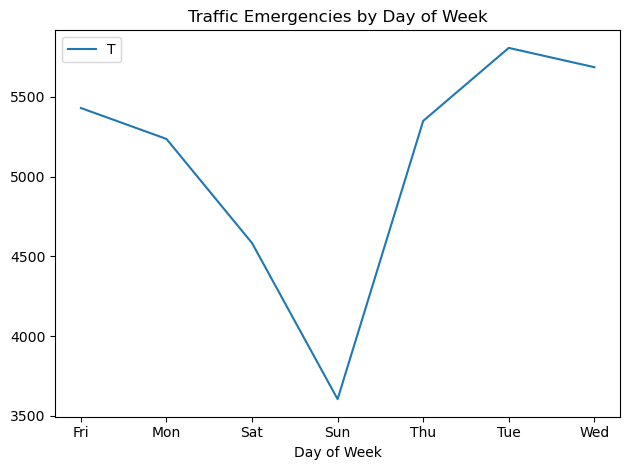

In [63]:
df[df['emergency'] == 'Traffic'].groupby('Day of Week').count()['emergency'].plot()
plt.title('Traffic Emergencies by Day of Week')
plt.tight_layout()
plt.legend('Traffic')

most common zip code for call 911 yearly 